In [1]:
# creating all the plot at the same time for each pruning percentage for single batch - ( 64) 


Processing pruning = 0.0


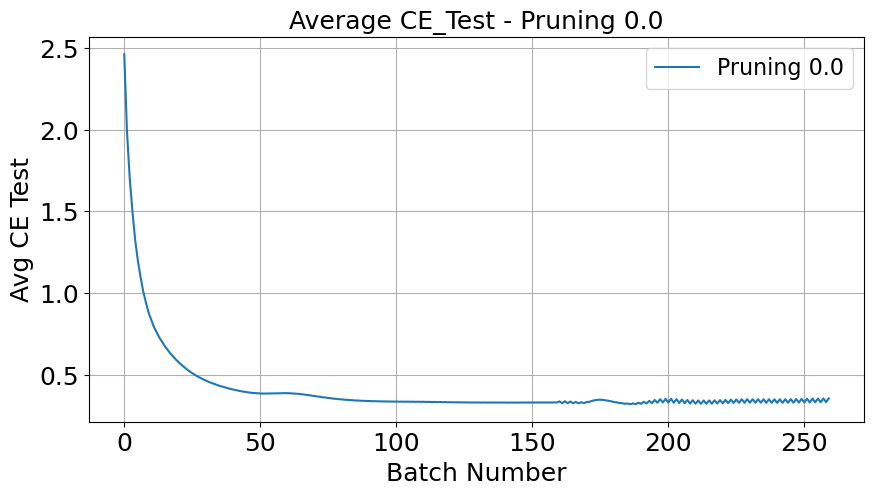


Processing pruning = 0.1


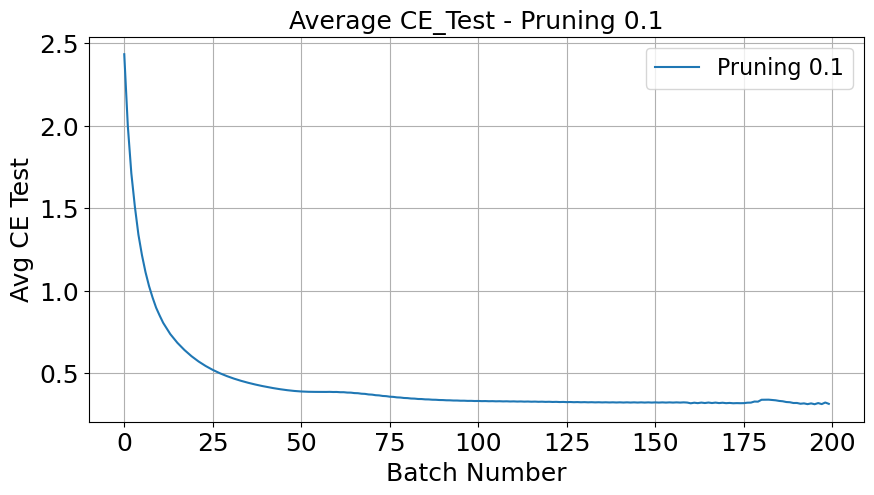


Processing pruning = 0.2


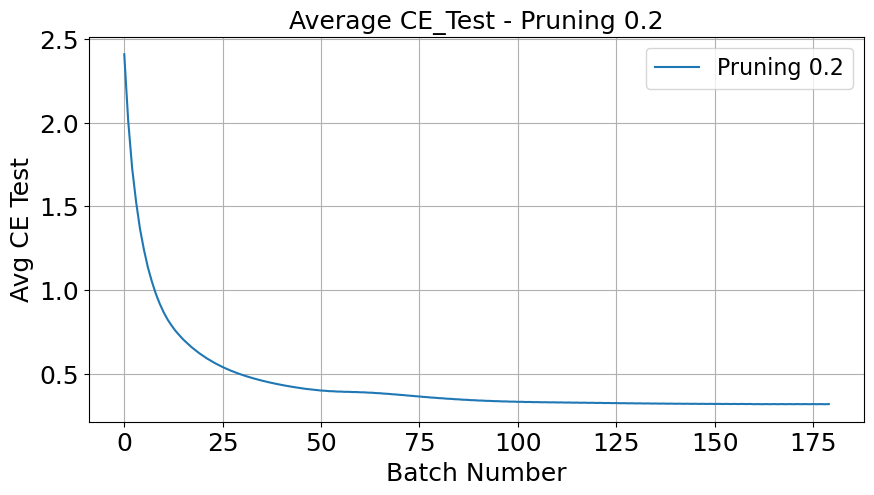


Processing pruning = 0.3


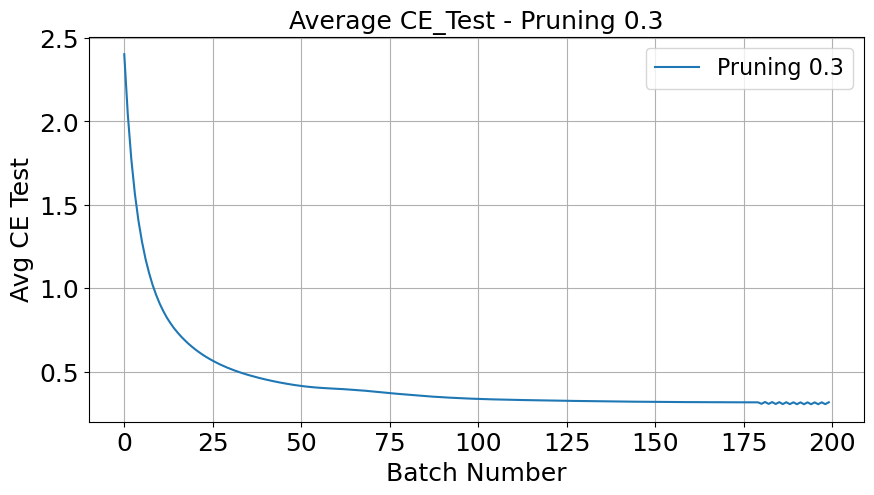


Processing pruning = 0.4


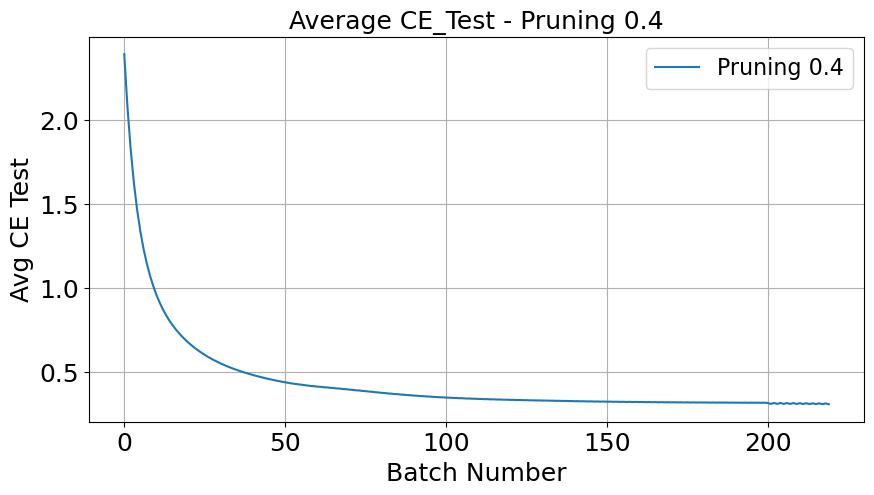


Processing pruning = 0.5


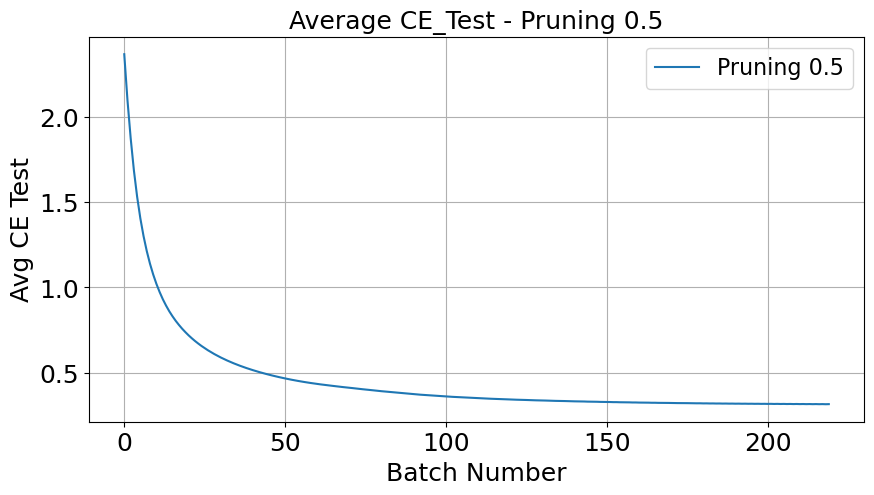


Processing pruning = 0.6


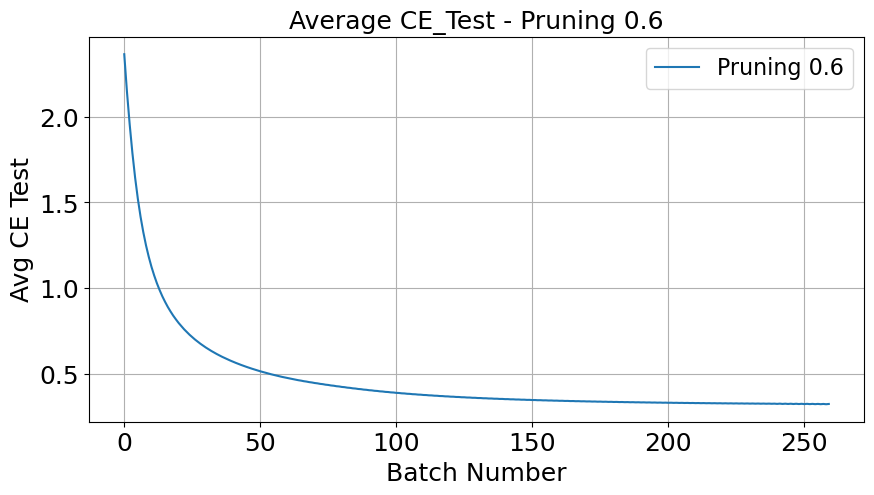


Processing pruning = 0.7


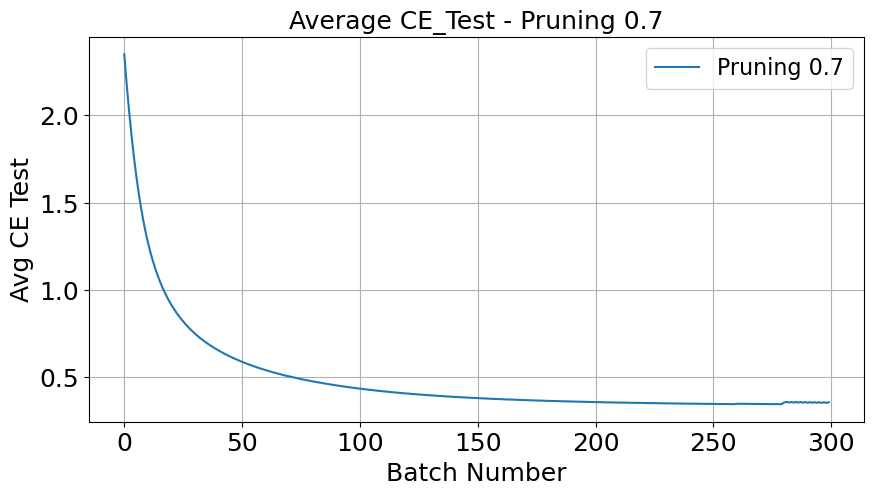


Processing pruning = 0.8


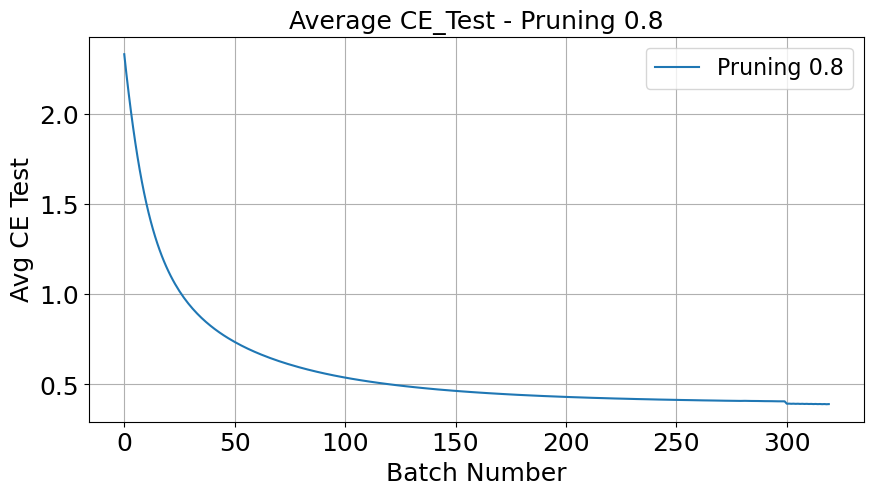


Processing pruning = 0.9


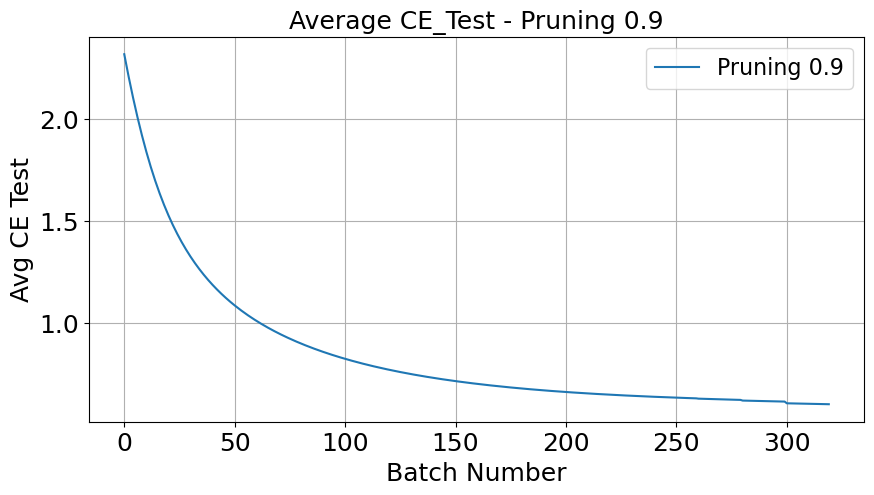


Processing pruning = 1.0


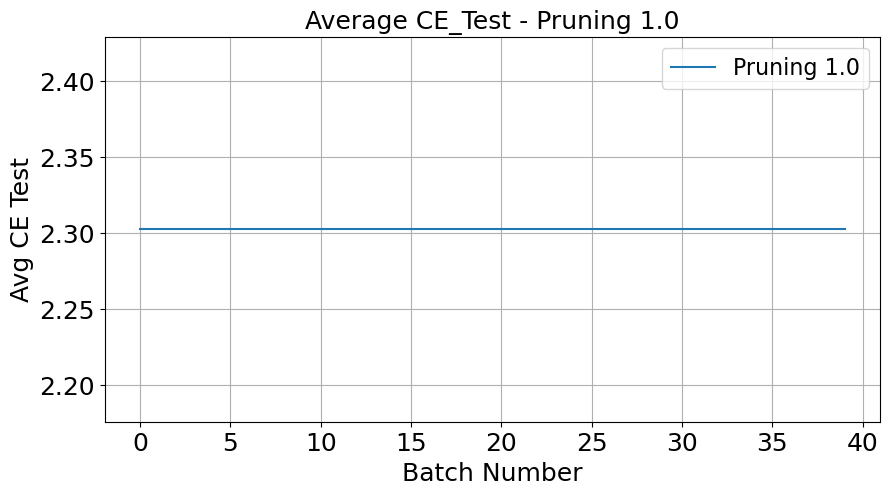

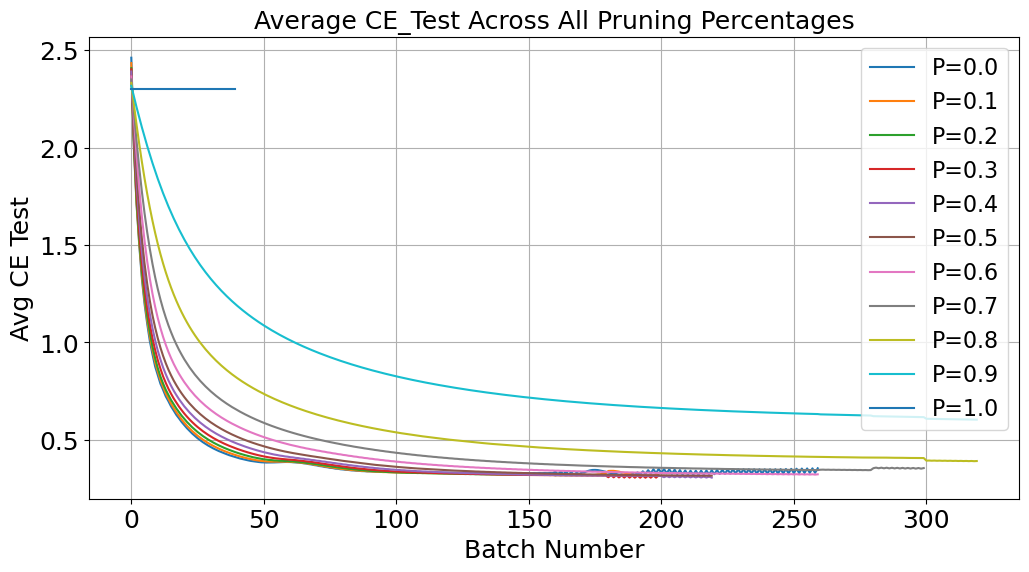

In [90]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL"
BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_60000"
FILE_PATTERN = "slp_{:.1f}_60000_run_*"

# =========================
# HELPER FUNCTION
# =========================
def average_runs_for_pruning(pruning_value):
    folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(pruning_value))
    pattern = FILE_PATTERN.format(pruning_value)

    files = glob.glob(os.path.join(folder, pattern))
    if len(files) == 0:
        print(f"[WARNING] No files found for pruning {pruning_value}")
        return None

    dfs = []
    for f in files:
        df = pd.read_csv(f, sep=r"\s+")
        df.columns = df.columns.str.strip()

        df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
        df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")
        df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")

        dfs.append(df)

    all_runs = pd.concat(dfs, ignore_index=True)

    avg_df = (
        all_runs.groupby("Batch_Number", as_index=False)
        .agg(
            Avg_CE_Train=("CE_Train", "mean"),
            Avg_Accuracy=("Accuracy(%)", "mean"),
            Avg_CE_Test=("CE_TEST", "mean"),
            Num_Runs=("CE_TEST", "count")
        )
    )

    out_csv = os.path.join(folder, f"averaged_runs_p_{pruning_value}.csv")
    avg_df.to_csv(out_csv, index=False)

    return avg_df

# =========================
# MAIN LOOP
# =========================
all_avg_dfs = {}  # store all dfs for combined plot

for p in np.arange(0.0, 1.01, 0.1):
    p = round(p, 1)
    print(f"\nProcessing pruning = {p}")

    avg_df = average_runs_for_pruning(p)
    if avg_df is None:
        continue

    all_avg_dfs[p] = avg_df

    # -------- individual plot for each pruning --------
    plt.figure(figsize=(10, 5))
    plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Test"], label=f"Pruning {p}")
    plt.xlabel("Batch Number")
    plt.ylabel("Avg CE Test")
    plt.title(f"Average CE_Test - Pruning {p}")
    plt.grid(True)
    plt.legend()
    plt.show()

# =========================
# COMBINED PLOT (All pruning percentages)
# =========================
plt.figure(figsize=(12, 6))

for p, avg_df in all_avg_dfs.items():
    plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Test"], label=f"P={p}")

plt.xlabel("Batch Number")
plt.ylabel("Avg CE Test")
plt.title("Average CE_Test Across All Pruning Percentages")
plt.grid(True)
plt.legend()
plt.show()


## single plot 

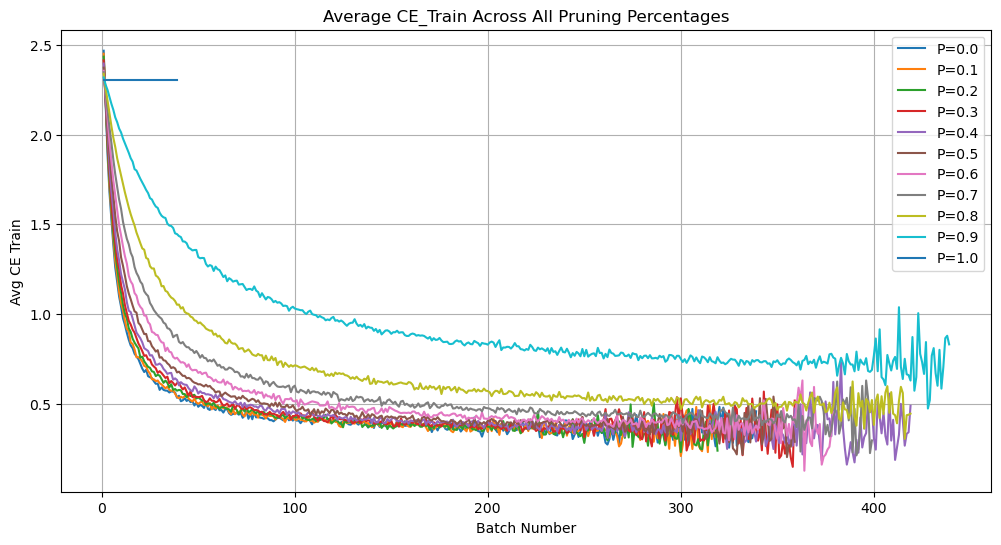

In [11]:

# =========================
# COMBINED PLOT (All pruning percentages)
# =========================
plt.figure(figsize=(12, 6))

for p, avg_df in all_avg_dfs.items():
    plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Train"], label=f"P={p}")

plt.xlabel("Batch Number")
plt.ylabel("Avg CE Train")
plt.title("Average CE_Train Across All Pruning Percentages")
plt.grid(True)
plt.legend()
plt.show()


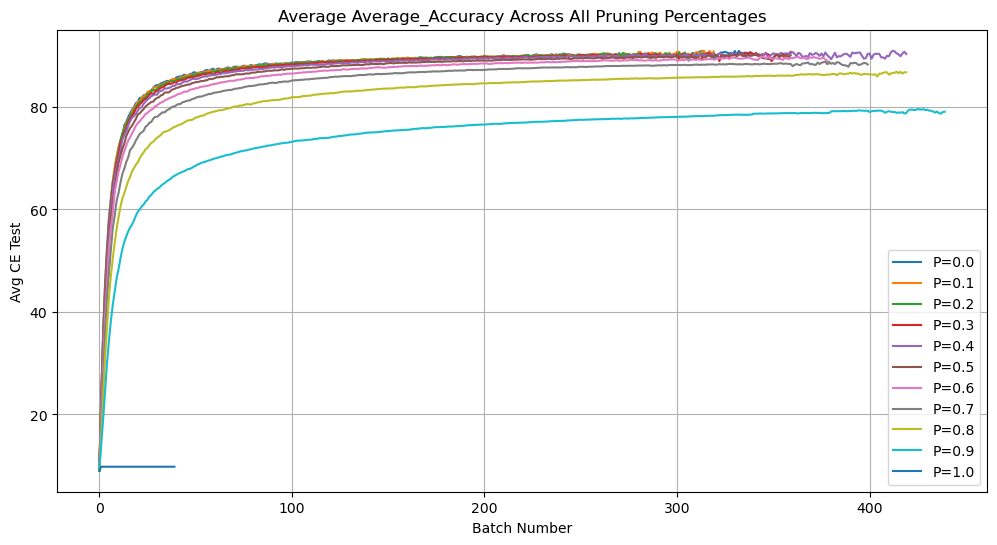

In [9]:

# =========================
# COMBINED PLOT (All pruning percentages)
# =========================
plt.figure(figsize=(12, 6))

for p, avg_df in all_avg_dfs.items():
    plt.plot(avg_df["Batch_Number"], avg_df["Avg_Accuracy"], label=f"P={p}")

plt.xlabel("Batch Number")
plt.ylabel("Avg CE Test")
plt.title("Average Average_Accuracy Across All Pruning Percentages")
plt.grid(True)
plt.legend()
plt.show()


## For batch size 1024 


Processing pruning = 0.0


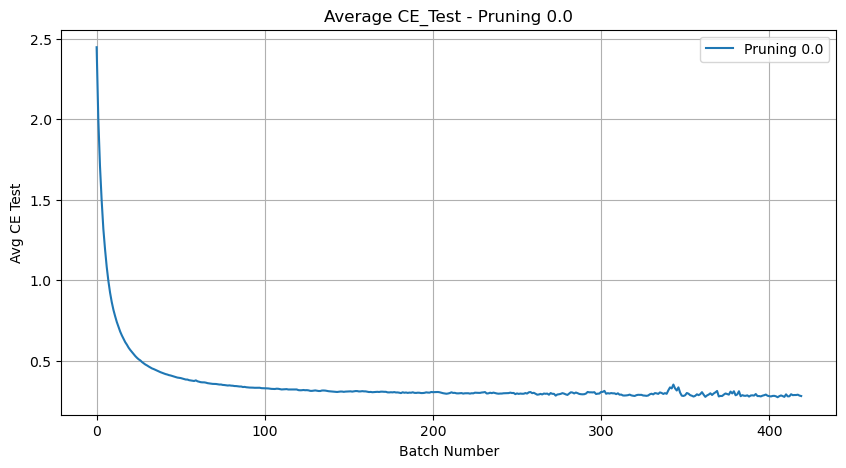


Processing pruning = 0.1


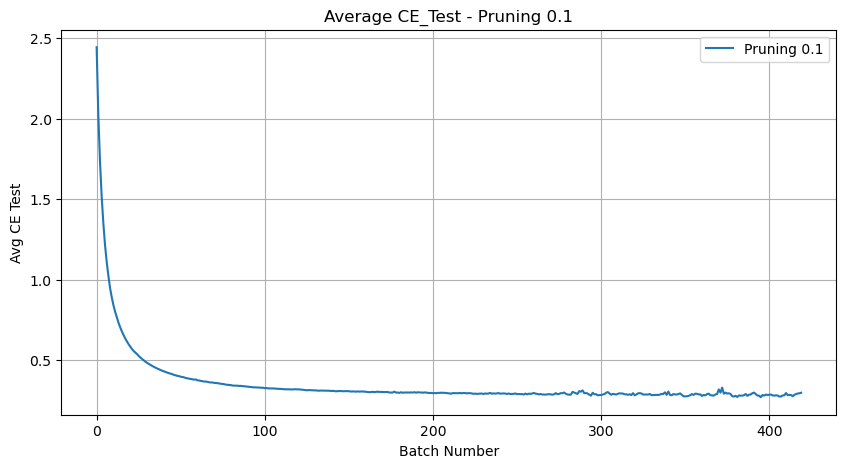


Processing pruning = 0.2


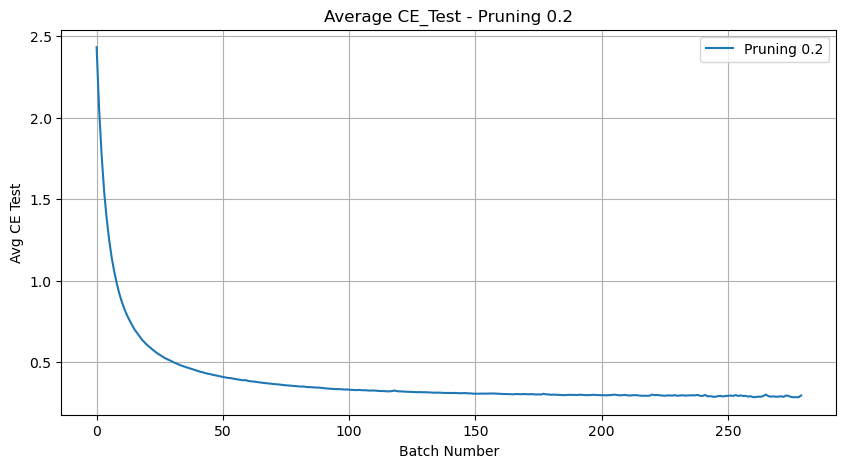


Processing pruning = 0.3


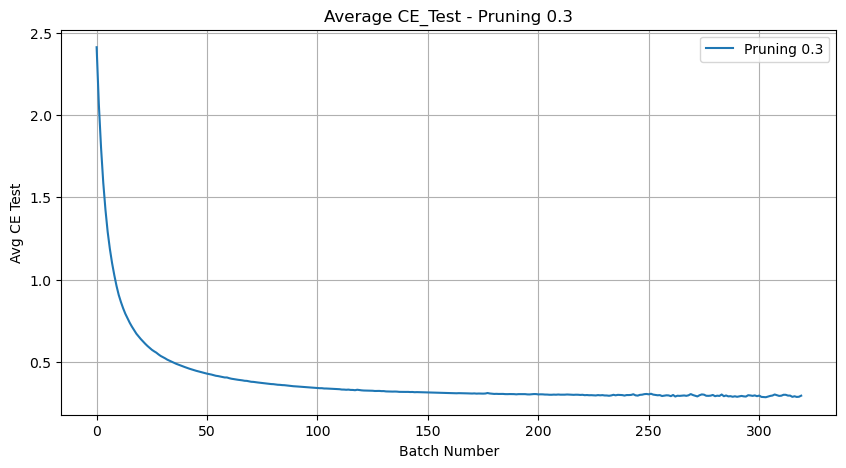


Processing pruning = 0.4


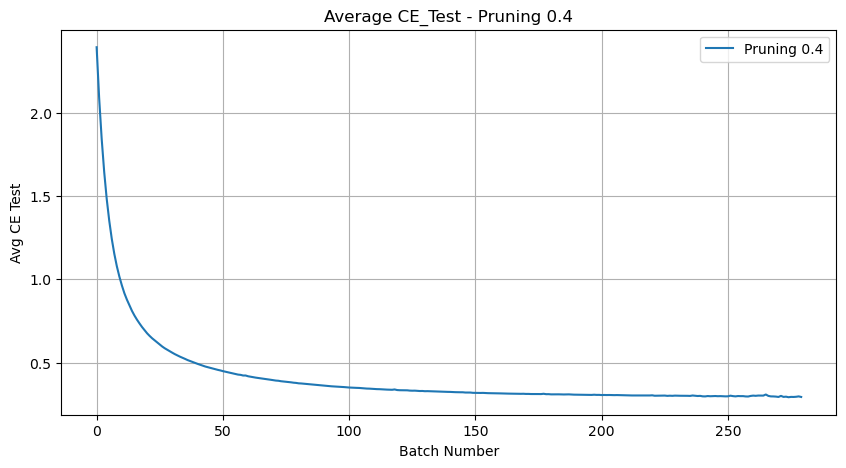


Processing pruning = 0.5


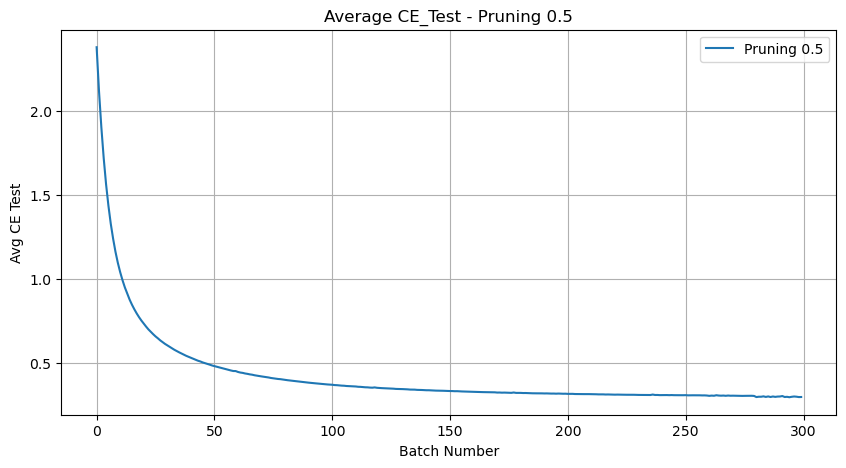


Processing pruning = 0.6


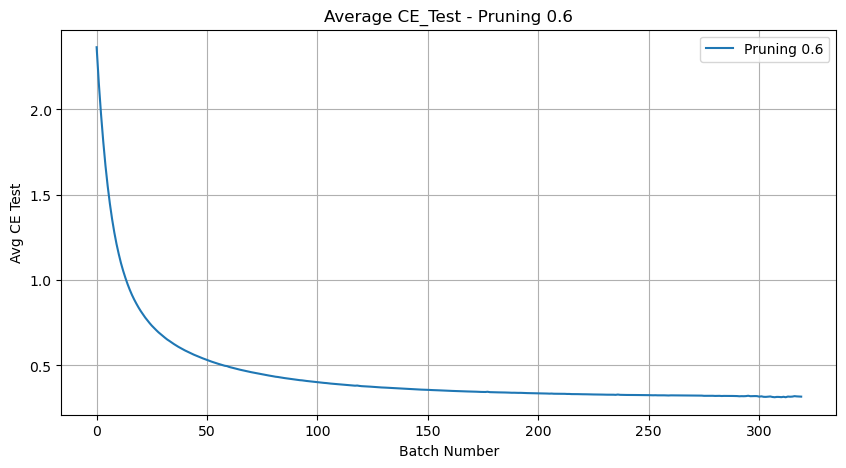


Processing pruning = 0.7


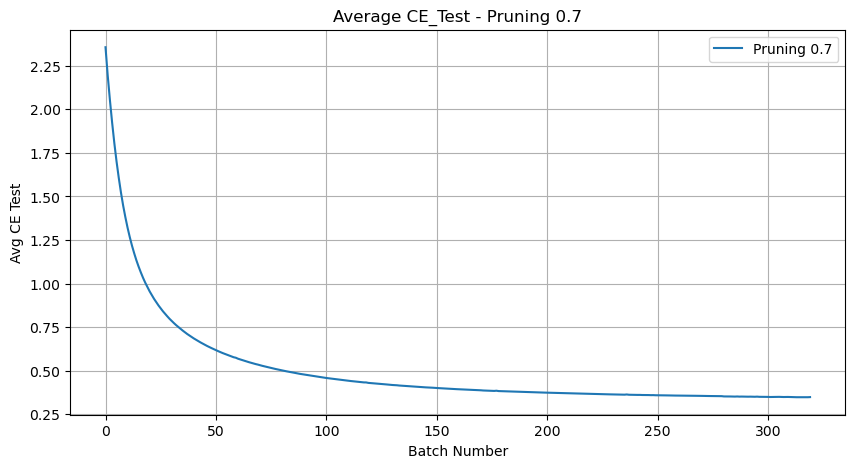


Processing pruning = 0.8


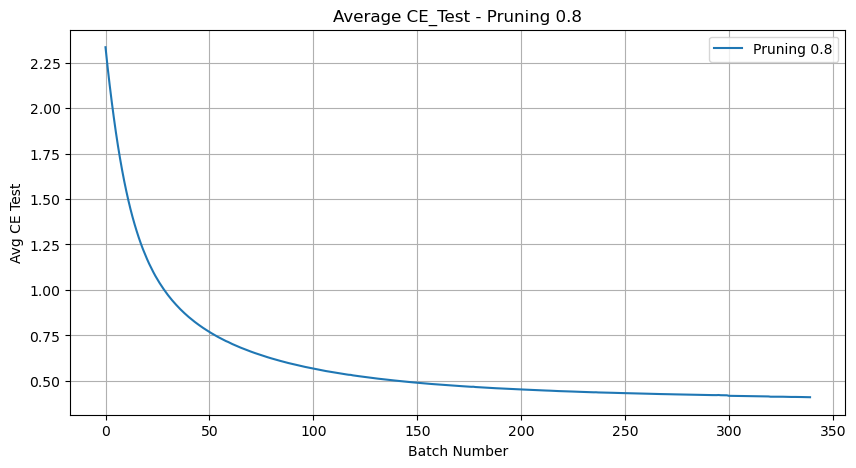


Processing pruning = 0.9


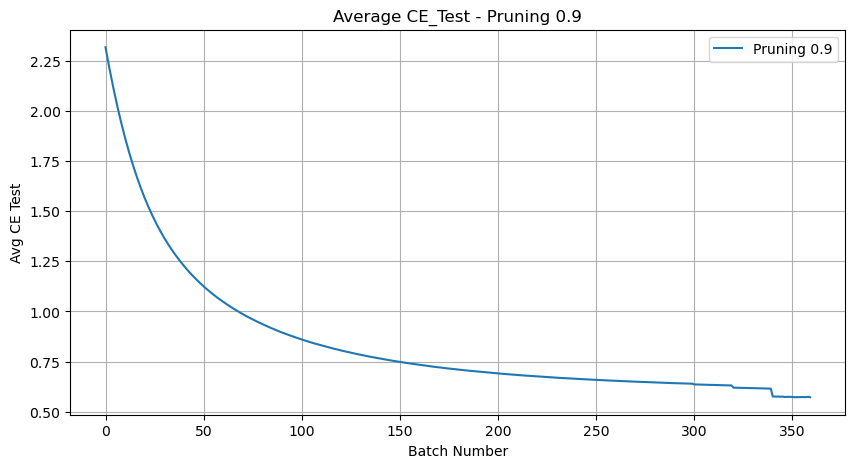


Processing pruning = 1.0


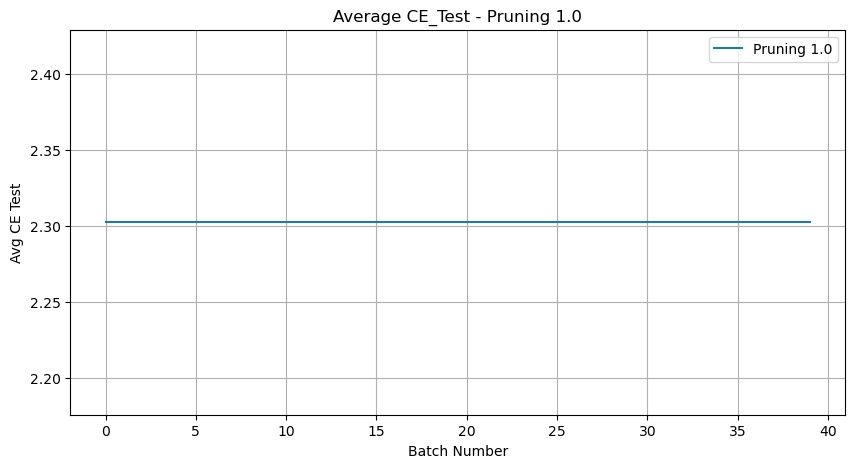

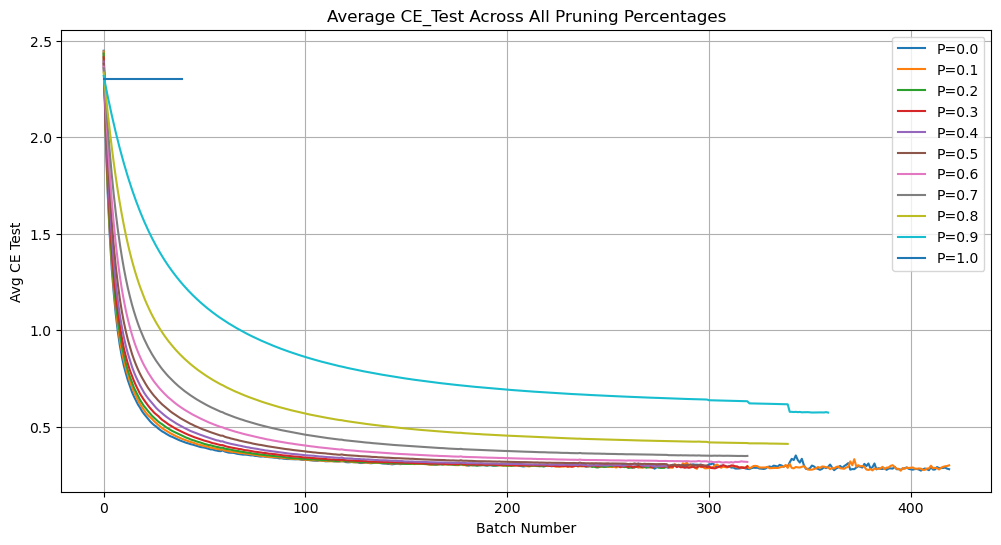

In [13]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL"
BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_1024"
FILE_PATTERN = "slp_{:.1f}_1024_run_*"

# =========================
# HELPER FUNCTION
# =========================
def average_runs_for_pruning(pruning_value):
    folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(pruning_value))
    pattern = FILE_PATTERN.format(pruning_value)

    files = glob.glob(os.path.join(folder, pattern))
    if len(files) == 0:
        print(f"[WARNING] No files found for pruning {pruning_value}")
        return None

    dfs = []
    for f in files:
        df = pd.read_csv(f, sep=r"\s+")
        df.columns = df.columns.str.strip()

        df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
        df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")
        df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")

        dfs.append(df)

    all_runs = pd.concat(dfs, ignore_index=True)

    avg_df = (
        all_runs.groupby("Batch_Number", as_index=False)
        .agg(
            Avg_CE_Train=("CE_Train", "mean"),
            Avg_Accuracy=("Accuracy(%)", "mean"),
            Avg_CE_Test=("CE_TEST", "mean"),
            Num_Runs=("CE_TEST", "count")
        )
    )

    out_csv = os.path.join(folder, f"averaged_runs_p_{pruning_value}.csv")
    avg_df.to_csv(out_csv, index=False)

    return avg_df

# =========================
# MAIN LOOP
# =========================
all_avg_dfs = {}  # store all dfs for combined plot

for p in np.arange(0.0, 1.01, 0.1):
    p = round(p, 1)
    print(f"\nProcessing pruning = {p}")

    avg_df = average_runs_for_pruning(p)
    if avg_df is None:
        continue

    all_avg_dfs[p] = avg_df

    # -------- individual plot for each pruning --------
    plt.figure(figsize=(10, 5))
    plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Test"], label=f"Pruning {p}")
    plt.xlabel("Batch Number")
    plt.ylabel("Avg CE Test")
    plt.title(f"Average CE_Test - Pruning {p}")
    plt.grid(True)
    plt.legend()
    plt.show()

# =========================
# COMBINED PLOT (All pruning percentages)
# =========================
plt.figure(figsize=(12, 6))

for p, avg_df in all_avg_dfs.items():
    plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Test"], label=f"P={p}")

plt.xlabel("Batch Number")
plt.ylabel("Avg CE Test")
plt.title("Average CE_Test Across All Pruning Percentages")
plt.grid(True)
plt.legend()
plt.show()


<Figure size 1200x600 with 0 Axes>

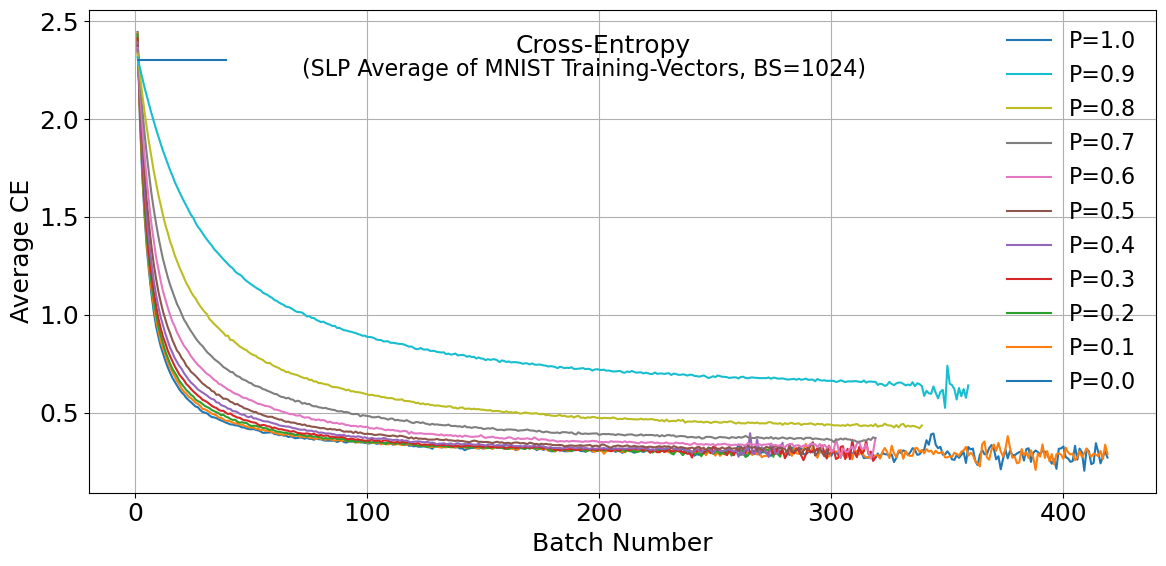

In [87]:
# =========================
# COMBINED PLOT (All pruning percentages)
# =========================
plt.figure(figsize=(12, 6))
plt.rcParams.update({
    "font.size": 18,           # double of 12
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# =========================
# COMBINED PLOT (All pruning percentages)
# =========================
plt.figure(figsize=(12, 6))

for p, avg_df in all_avg_dfs.items():
    plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Train"], label=f"P={p}")

plt.xlabel("Batch Number")
plt.ylabel("Average CE")

plt.text(
    0.40, 0.95,
    "Cross-Entropy",
    
    transform=plt.gca().transAxes,
    va='top'
)

plt.text(
    0.20, 0.90,
    "(SLP Average of MNIST Training-Vectors, BS=1024)",   
    fontsize=16,
    
    transform=plt.gca().transAxes,
    va='top'
)

# plt.legend(loc="upper right", frameon=False)[::-1]
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc="upper right", frameon=False)
plt.grid(True)
plt.tight_layout()
plt.savefig("CE-Avg_SLP_MNIST-Train-BS_1024.png", bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
## working code that calculate the averages for all the run and plot 

In [ ]:
import pandas as pd
# import glob
# import os
# import matplotlib.pyplot as plt

# # =========================
# # CONFIG
# # =========================
# BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-FMNIST\prune_layers_ALL"
# BATCH_DIR_TEMPLATE = "p-percentage_{:.1f}\\batch_size_{}"
# FILE_PATTERN = "slp_{:.1f}_{}_run_*"

# BATCH_SIZES = [64, 1024, 60000]

# # =========================
# # STYLE (Nature-like)
# # =========================
# plt.rcParams.update({
#     "font.size": 18,
#     "axes.titlesize": 18,
#     "axes.labelsize": 18,
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 16
# })

# # =========================
# # LOOP OVER BATCH SIZES
# # =========================
# for bs in BATCH_SIZES:
#     all_avg_dfs = {}

#     for p in [round(x*0.1,1) for x in range(0,11)]:
#         folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
#         pattern = FILE_PATTERN.format(p, bs)
#         files = glob.glob(os.path.join(folder, pattern))

#         if not files:
#             print(f"[WARNING] No files found for pruning {p} and batch size {bs}")
#             continue

#         # =========================
#         # LOAD ALL RUNS
#         # =========================
#         dfs = []
#         for f in files:
#             df = pd.read_csv(f, sep=r"\s+")
#             df.columns = df.columns.str.strip()

#             df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
#             df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")
#             df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")

#             dfs.append(df)

#         all_runs = pd.concat(dfs, ignore_index=True)

#         # =========================
#         # GROUP + AVERAGE
#         # =========================
#         avg_df = all_runs.groupby("Batch_Number", as_index=False).agg(
#             Avg_CE_Train=("CE_Train", "mean"),
#             Avg_CE_Test=("CE_TEST", "mean"),
#             Avg_Accuracy=("Accuracy(%)", "mean"),
#             Num_Runs=("CE_TEST", "count")
#         )

#         # =========================
#         # SAVE CSV
#         # =========================
#         out_csv = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")
#         avg_df.to_csv(out_csv, index=False)

#         all_avg_dfs[p] = avg_df

#     # =========================
#     # COMBINED PLOT (CE_Train)
#     # =========================
#     plt.figure(figsize=(12, 6))

#     for p, avg_df in all_avg_dfs.items():
#         plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Train"], label=f"P={p}")

#     plt.xlabel("Batch Number")
#     plt.ylabel("Average CE")

#     plt.text(0.40, 0.95, "Cross-Entropy", transform=plt.gca().transAxes, va='top')
#     plt.text(0.20, 0.90, f"(SLP Average of FMNIST Training-Vectors, BS={bs})",
#              fontsize=16, transform=plt.gca().transAxes, va='top')

#     handles, labels = plt.gca().get_legend_handles_labels()
#     plt.legend(handles[::-1], labels[::-1], loc="upper right", frameon=False)

#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig(f"CE_Train_Avg_SLP_FMNIST_BS_{bs}.png", bbox_inches='tight', dpi=300)
#     plt.show()

#     # =========================
#     # COMBINED PLOT (CE_Test)
#     # =========================
#     plt.figure(figsize=(12, 6))

#     for p, avg_df in all_avg_dfs.items():
#         plt.plot(avg_df["Batch_Number"], avg_df["Avg_CE_Test"], label=f"P={p}")

#     plt.xlabel("Batch Number")
#     plt.ylabel("Average CE")

#     plt.text(0.40, 0.95, "Cross-Entropy", transform=plt.gca().transAxes, va='top')
#     plt.text(0.20, 0.90, f"(SLP Average of FMNIST Test-Vectors, BS={bs})",
#              fontsize=16, transform=plt.gca().transAxes, va='top')

#     handles, labels = plt.gca().get_legend_handles_labels()
#     plt.legend(handles[::-1], labels[::-1], loc="upper right", frameon=False)

#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig(f"CE_Test_Avg_SLP_FMNIST_BS_{bs}.png", bbox_inches='tight', dpi=300)
#     plt.show()



#     # =========================
#     # COMBINED PLOT (Accuracy)
#     # =========================
#     plt.figure(figsize=(12, 6))

#     for p, avg_df in all_avg_dfs.items():
#         plt.plot(avg_df["Batch_Number"], avg_df["Avg_Accuracy"], label=f"P={p}")

#     plt.xlabel("Batch Number")
#     plt.ylabel("Average Accuracy")

#     plt.text(0.40, 0.55, "Accuracy", transform=plt.gca().transAxes, va='top')
#     plt.text(0.20, 0.50, f"(SLP Average of FMNIST Test-Vectors, BS={bs})",
#              fontsize=16, transform=plt.gca().transAxes, va='top')

#     # handles, labels = plt.gca().get_legend_handles_labels()
#     plt.legend(
#         # handles[::-1], labels[::-1],
#                loc="upper right", frameon=False)

#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig(f"Accuracy_Avg_SLP_FMNIST_BS_{bs}.png", bbox_inches='tight', dpi=300)
#     plt.show()

    

